## **Import Libraries and modules**

In [ ]:
import numpy as np

from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D, Lambda

from keras.utils import np_utils

from keras.datasets import mnist

## Load MNIST data into train and test sets

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11493376/11490434 [==============================] - 0s 0us/step


(60000, 28, 28)


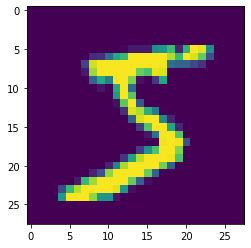

In [ ]:
print (X_train.shape)
from matplotlib import pyplot as plt
%matplotlib inline
plt.imshow(X_train[0])

## Pre-processing

### Reshaping data

In [ ]:
X_train = X_train.reshape(X_train.shape[0], 28, 28,1)
X_test = X_test.reshape(X_test.shape[0], 28, 28,1)

### Pixel Normalization

0 - black, 255 - white then by dividing we are making it either 0 or 1


In [ ]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255

In [ ]:
y_train[:10]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4], dtype=uint8)

### One-hot encoding

In [ ]:
# Convert 1-dimensional class arrays to 10-dimensional class matrices
Y_train = np_utils.to_categorical(y_train, 10)
Y_test = np_utils.to_categorical(y_test, 10)

In [ ]:
Y_train[:10]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]], dtype=float32)

## Model - NN without hidden layer

In [ ]:
nn_without_hidden = Sequential()

nn_without_hidden.add(Flatten(input_shape=(28, 28, 1)))
#nn_without_hidden.add(Lambda(identity, input_shape=(28,28,1)))
#nn_without_hidden.add(Flatten())

nn_without_hidden.add(Dense(10, activation='softmax'))

nn_without_hidden.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten (Flatten)            (None, 784)               0         
_________________________________________________________________
dense (Dense)                (None, 10)                7850      
Total params: 7,850
Trainable params: 7,850
Non-trainable params: 0
_________________________________________________________________


In [ ]:
nn_without_hidden.compile(loss='categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])

In [ ]:
nn_without_hidden.fit(X_train, Y_train, batch_size=32, epochs=10, validation_data=(X_test, Y_test))

Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 11s 186us/step - loss: 0.4734 - acc: 0.8763 - val_loss: 0.3097 - val_acc: 0.9128
Epoch 2/10
60000/60000 [==============================] - 7s 119us/step - loss: 0.3040 - acc: 0.9153 - val_loss: 0.2833 - val_acc: 0.9201
Epoch 3/10
60000/60000 [==============================] - 7s 122us/step - loss: 0.2835 - acc: 0.9205 - val_loss: 0.2740 - val_acc: 0.9256
Epoch 4/10
60000/60000 [==============================] - 7s 120us/step - loss: 0.2728 - acc: 0.9234 - val_loss: 0.2686 - val_acc: 0.9257
Epoch 5/10
60000/60000 [==============================] - 7s 119us/step - loss: 0.2669 - acc: 0.9258 - val_loss: 0.2691 - val_acc: 0.9267
Epoch 6/10
60000/60000 [==============================] - 7s 120us/step - loss: 0.2622 - acc: 0.9273 - val_loss: 0.2645 - val_acc: 0.9262
Epoch 7/10
60000/60000 [==============================] - 7s 120us/step - loss: 0.2579 - acc: 0.9283 - val_loss: 0.2626 -

#### Observation -- Train_acc: 93.0%  val_acc: 92.79%





## Model - NN with hidden layer

In [ ]:
nn_with_hidden = Sequential()

nn_with_hidden.add(Lambda(identity, input_shape=(28,28,1)))
nn_with_hidden.add(Flatten())
nn_with_hidden.add(Dense(48, activation='relu'))
nn_with_hidden.add(Dense(10, activation='softmax'))

nn_with_hidden.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lambda_7 (Lambda)            (None, 28, 28, 1)         0         
_________________________________________________________________
flatten_21 (Flatten)         (None, 784)               0         
_________________________________________________________________
dense_9 (Dense)              (None, 48)                37680     
_________________________________________________________________
dense_10 (Dense)             (None, 10)                490       
Total params: 38,170
Trainable params: 38,170
Non-trainable params: 0
_________________________________________________________________


In [ ]:
nn_with_hidden.compile(loss='categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])

In [ ]:
nn_with_hidden.fit(X_train, Y_train, batch_size=32, epochs=10, validation_data=(X_test, Y_test))

Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 12s 204us/step - loss: 0.3265 - acc: 0.9070 - val_loss: 0.1918 - val_acc: 0.9420
Epoch 2/10
60000/60000 [==============================] - 8s 130us/step - loss: 0.1679 - acc: 0.9504 - val_loss: 0.1430 - val_acc: 0.9588
Epoch 3/10
60000/60000 [==============================] - 8s 130us/step - loss: 0.1257 - acc: 0.9632 - val_loss: 0.1226 - val_acc: 0.9635
Epoch 4/10
60000/60000 [==============================] - 8s 130us/step - loss: 0.1006 - acc: 0.9698 - val_loss: 0.1129 - val_acc: 0.9652
Epoch 5/10
60000/60000 [==============================] - 8s 129us/step - loss: 0.0853 - acc: 0.9741 - val_loss: 0.0998 - val_acc: 0.9687
Epoch 6/10
60000/60000 [==============================] - 8s 130us/step - loss: 0.0731 - acc: 0.9778 - val_loss: 0.0983 - val_acc: 0.9694
Epoch 7/10
60000/60000 [==============================] - 8s 130us/step - loss: 0.0637 - acc: 0.9801 - val_loss: 0.0928 -

#### Obseration -- Train_acc: 98.6%  val_acc: 96.94%




## Model Building -- Using Convolution Layers

In [ ]:
model = Sequential()

model.add(Conv2D(8, 3, 3, activation='relu', input_shape=(28,28,1)))

model.add(Conv2D(16, 3, 3, activation='relu')) # 8 * 16 * 3 * 3 + 16
model.add(Conv2D(32, 3, 3, activation='relu'))

model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(8, 1, 1, activation='relu'))

model.add(Conv2D(16, 3, 3, activation='relu'))
model.add(Conv2D(16, 3, 3, activation='relu'))

model.add(Conv2D(10, 1, activation='relu'))
model.add(Conv2D(10, 7))

model.add(Flatten())
model.add(Activation('softmax'))

model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_89 (Conv2D)           (None, 26, 26, 8)         80        
_________________________________________________________________
conv2d_90 (Conv2D)           (None, 24, 24, 16)        1168      
_________________________________________________________________
conv2d_91 (Conv2D)           (None, 22, 22, 32)        4640      
_________________________________________________________________
max_pooling2d_12 (MaxPooling (None, 11, 11, 32)        0         
_________________________________________________________________
conv2d_92 (Conv2D)           (None, 11, 11, 8)         264       
_________________________________________________________________
conv2d_93 (Conv2D)           (None, 9, 9, 16)          1168      
_________________________________________________________________
conv2d_94 (Conv2D)           (None, 7, 7, 16)          2320      
__________

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:3: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(8, (3, 3), activation="relu", input_shape=(28, 28, 1...)`
  This is separate from the ipykernel package so we can avoid doing imports until
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:5: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(16, (3, 3), activation="relu")`
  """
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:6: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(32, (3, 3), activation="relu")`
  
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:9: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(8, (1, 1), activation="relu")`
  if __name__ == '__main__':
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:11: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(16, (3, 3), activation="relu")`
  # This is added back by InteractiveSh

In [ ]:
model.compile(loss='categorical_crossentropy',
             optimizer='sgd',
             metrics=['accuracy'])

model.fit(X_train, Y_train, batch_size=32, epochs=10, verbose=1)

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:1: UserWarning: The `nb_epoch` argument in `fit` has been renamed `epochs`.
  """Entry point for launching an IPython kernel.
W0730 05:04:23.203318 140265672845184 deprecation.py:323] From /usr/local/lib/python3.6/dist-packages/tensorflow/python/ops/math_grad.py:1250: add_dispatch_support.<locals>.wrapper (from tensorflow.python.ops.array_ops) is deprecated and will be removed in a future version.
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
W0730 05:04:23.279221 140265672845184 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:986: The name tf.assign_add is deprecated. Please use tf.compat.v1.assign_add instead.



Epoch 1/10
60000/60000 [==============================] - 11s 183us/step - loss: 0.7377 - acc: 0.7567
Epoch 2/10
60000/60000 [==============================] - 8s 141us/step - loss: 0.1451 - acc: 0.9567
Epoch 3/10
60000/60000 [==============================] - 8s 140us/step - loss: 0.1037 - acc: 0.9692
Epoch 4/10
60000/60000 [==============================] - 8s 140us/step - loss: 0.0856 - acc: 0.9739
Epoch 5/10
60000/60000 [==============================] - 9s 146us/step - loss: 0.0737 - acc: 0.9776
Epoch 6/10
60000/60000 [==============================] - 9s 144us/step - loss: 0.0665 - acc: 0.9798
Epoch 7/10
60000/60000 [==============================] - 8s 140us/step - loss: 0.0601 - acc: 0.9814
Epoch 8/10
60000/60000 [==============================] - 8s 140us/step - loss: 0.0554 - acc: 0.9829
Epoch 9/10
60000/60000 [==============================] - 8s 140us/step - loss: 0.0521 - acc: 0.9835
Epoch 10/10
60000/60000 [==============================] - 8s 141us/step - loss: 0.0488 - 

### Model Evaluation

In [ ]:
score = model.evaluate(X_test, Y_test, verbose=0)
print(score)

[0.0506971247544745, 0.984]


### Model Prediction

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print(y_pred[:9])
print(y_test[:9])

[[3.23383659e-07 7.14301365e-08 2.22758481e-05 2.99928884e-04
  1.63534128e-12 8.45612291e-09 3.39801246e-18 9.99670148e-01
  1.10206520e-06 6.21200979e-06]
 [1.15960279e-06 5.77195169e-06 9.99992132e-01 3.74984097e-07
  6.14736317e-10 1.09894507e-11 2.73345546e-09 3.27461392e-13
  6.05238938e-07 1.19068628e-15]
 [2.93268636e-06 9.99083877e-01 1.62235665e-04 4.01818870e-05
  4.85967212e-05 1.30269482e-05 5.04804302e-05 3.25564441e-04
  2.67411524e-04 5.51321182e-06]
 [9.99978900e-01 5.65062552e-10 7.26580595e-07 3.21644350e-10
  5.80561128e-08 7.16092359e-08 6.15807312e-06 1.36471430e-08
  5.51320092e-08 1.40077791e-05]
 [1.24681945e-10 1.65146585e-09 9.32828148e-10 1.02773234e-10
  9.99505043e-01 7.37640782e-10 2.13695173e-09 6.02243347e-07
  8.33877589e-09 4.94304346e-04]
 [4.42877621e-07 9.99695063e-01 2.10189301e-05 1.74804973e-05
  2.33889259e-05 6.86197495e-07 1.71520514e-06 1.16176627e-04
  1.22098558e-04 2.00545355e-06]
 [2.25580904e-12 2.63387733e-06 1.31810668e-06 6.32025055e

### Observation -- Train_acc: 98.5%  val_acc: 98.4%

The training accuracy is increasing over epochs.

When compare to the model with no convolution layer, it is far better as the validation accuracy is higher and the number of parameters are way too less comparatively.

Validation accuracy is lower than training accuracy. There is a hint of over-fitting here.

Let us try different techniques to address it.



## Dropout

Let us dropout of 10% after every layer.

In [ ]:
from keras.layers import Activation
model = Sequential()

model.add(Conv2D(8, 3, 3, activation='relu', input_shape=(28,28,1)))
model.add(Dropout(0.1))

model.add(Conv2D(16, 3, 3, activation='relu'))
model.add(Dropout(0.1))

model.add(Conv2D(32, 3, 3, activation='relu'))
model.add(Dropout(0.1))

model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(8, 1, 1, activation='relu'))

model.add(Conv2D(16, 3, 3, activation='relu'))
model.add(Dropout(0.1))

model.add(Conv2D(16, 3, 3, activation='relu'))
model.add(Dropout(0.1))

model.add(Conv2D(10, 1, activation='relu'))
model.add(Conv2D(10, 7))

model.add(Flatten())
model.add(Activation('softmax'))

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:4: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(8, (3, 3), activation="relu", input_shape=(28, 28, 1...)`
  after removing the cwd from sys.path.
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:7: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(16, (3, 3), activation="relu")`
  import sys
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:10: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(32, (3, 3), activation="relu")`
  # Remove the CWD from sys.path while we load stuff.
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:14: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(8, (1, 1), activation="relu")`
  
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:16: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(16, (3, 3), activation="relu")`
  app.launch_new_instance()
/usr/local/lib/pyth

In [ ]:
model.compile(loss='categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])

model.fit(X_train, Y_train, batch_size=32, epochs=10, verbose=1, validation_data=(X_test, Y_test))

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:5: UserWarning: The `nb_epoch` argument in `fit` has been renamed `epochs`.
  """


Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 16s 272us/step - loss: 0.2491 - acc: 0.9214 - val_loss: 0.0865 - val_acc: 0.9727
Epoch 2/10
60000/60000 [==============================] - 14s 225us/step - loss: 0.0821 - acc: 0.9749 - val_loss: 0.0449 - val_acc: 0.9853
Epoch 3/10
60000/60000 [==============================] - 14s 225us/step - loss: 0.0615 - acc: 0.9804 - val_loss: 0.0434 - val_acc: 0.9869
Epoch 4/10
60000/60000 [==============================] - 14s 227us/step - loss: 0.0496 - acc: 0.9844 - val_loss: 0.0444 - val_acc: 0.9863
Epoch 5/10
60000/60000 [==============================] - 14s 225us/step - loss: 0.0443 - acc: 0.9859 - val_loss: 0.0345 - val_acc: 0.9881
Epoch 6/10
60000/60000 [==============================] - 13s 224us/step - loss: 0.0388 - acc: 0.9880 - val_loss: 0.0345 - val_acc: 0.9896
Epoch 7/10
60000/60000 [==============================] - 14s 225us/step - loss: 0.0346 - acc: 0.9884 - val_loss: 0.

#### Observation -- Train_acc: 99.08%  val_acc: 99.20%

Training accuracy is lower than validation accuracy -- this is understandable as Dropout is applied only during the training phase and not validation phase.

Let us see the performance of Batch Normalization instead of Dropout, to address the over-fitting.




## Model - Batch Normalization

In [ ]:
from keras.layers import Activation, BatchNormalization
model = Sequential()

model.add(Conv2D(8, 3, 3, activation='relu', input_shape=(28,28,1)))
model.add(BatchNormalization())

model.add(Conv2D(16, 3, 3, activation='relu'))
model.add(BatchNormalization())

model.add(Conv2D(16, 3, 3, activation='relu'))
model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(8, 1, 1, activation='relu'))
model.add(BatchNormalization())

model.add(Conv2D(16, 3, 3, activation='relu'))
model.add(BatchNormalization())

model.add(Conv2D(16, 3, 3, activation='relu'))
model.add(BatchNormalization())

model.add(Conv2D(10, 1, activation='relu'))
#model.add(BatchNormalization())

model.add(Conv2D(10, 7))

model.add(Flatten())
model.add(Activation('softmax'))

model.summary()

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:4: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(8, (3, 3), activation="relu", input_shape=(28, 28, 1...)`
  after removing the cwd from sys.path.
W0730 05:12:24.364202 140265672845184 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:1834: The name tf.nn.fused_batch_norm is deprecated. Please use tf.compat.v1.nn.fused_batch_norm instead.

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:7: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(16, (3, 3), activation="relu")`
  import sys
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:10: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(16, (3, 3), activation="relu")`
  # Remove the CWD from sys.path while we load stuff.
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:14: UserWarning: Update your `Conv2D` call to the Keras 2 API: 

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_17 (Conv2D)           (None, 26, 26, 8)         80        
_________________________________________________________________
batch_normalization_1 (Batch (None, 26, 26, 8)         32        
_________________________________________________________________
conv2d_18 (Conv2D)           (None, 24, 24, 16)        1168      
_________________________________________________________________
batch_normalization_2 (Batch (None, 24, 24, 16)        64        
_________________________________________________________________
conv2d_19 (Conv2D)           (None, 22, 22, 16)        2320      
_________________________________________________________________
batch_normalization_3 (Batch (None, 22, 22, 16)        64        
_________________________________________________________________
max_pooling2d_3 (MaxPooling2 (None, 11, 11, 16)        0         
__________

In [ ]:
model.compile(loss='categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])

model.fit(X_train, Y_train, batch_size=32, epochs=10, verbose=1, validation_data=(X_test, Y_test))

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:5: UserWarning: The `nb_epoch` argument in `fit` has been renamed `epochs`.
  """


Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 21s 355us/step - loss: 0.1414 - acc: 0.9559 - val_loss: 0.0512 - val_acc: 0.9846
Epoch 2/10
60000/60000 [==============================] - 20s 332us/step - loss: 0.0501 - acc: 0.9833 - val_loss: 0.0557 - val_acc: 0.9834
Epoch 3/10
60000/60000 [==============================] - 20s 332us/step - loss: 0.0405 - acc: 0.9872 - val_loss: 0.0483 - val_acc: 0.9839
Epoch 4/10
60000/60000 [==============================] - 20s 330us/step - loss: 0.0321 - acc: 0.9899 - val_loss: 0.0276 - val_acc: 0.9915
Epoch 5/10
60000/60000 [==============================] - 20s 332us/step - loss: 0.0293 - acc: 0.9905 - val_loss: 0.0253 - val_acc: 0.9908
Epoch 6/10
60000/60000 [==============================] - 20s 330us/step - loss: 0.0257 - acc: 0.9917 - val_loss: 0.0338 - val_acc: 0.9896
Epoch 7/10
60000/60000 [==============================] - 20s 329us/step - loss: 0.0226 - acc: 0.9924 - val_loss: 0.

#### Observation -- Train_acc: 99.48%  val_acc: 99.08%


We see that validation accuracy < training accuracy and there are clear signs of over-fitting.

However, the model's performance in 10 epochs is better.

Let us build a model with both BatchNorm and Dropout.

## Model - Batch Normalization and Dropout

In [ ]:
from keras.layers import Activation, BatchNormalization
model = Sequential()

model.add(Conv2D(8, 3, 3, activation='relu', input_shape=(28,28,1)))
model.add(BatchNormalization())
model.add(Dropout(0.1))

model.add(Conv2D(16, 3, 3, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.1))

model.add(Conv2D(16, 3, 3, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.1))

model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(8, 1, 1, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.1))

model.add(Conv2D(16, 3, 3, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.1))

model.add(Conv2D(16, 3, 3, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.1))

model.add(Conv2D(10, 1, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.1))

model.add(Conv2D(10, 7))

model.add(Flatten())
model.add(Activation('softmax'))

model.summary()

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:4: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(8, (3, 3), activation="relu", input_shape=(28, 28, 1...)`
  after removing the cwd from sys.path.
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:8: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(16, (3, 3), activation="relu")`
  
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:12: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(16, (3, 3), activation="relu")`
  if sys.path[0] == '':
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:17: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(8, (1, 1), activation="relu")`
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:21: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(16, (3, 3), activation="relu")`
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:25: UserWarning: Update your 

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_113 (Conv2D)          (None, 26, 26, 8)         80        
_________________________________________________________________
batch_normalization_50 (Batc (None, 26, 26, 8)         32        
_________________________________________________________________
dropout_65 (Dropout)         (None, 26, 26, 8)         0         
_________________________________________________________________
conv2d_114 (Conv2D)          (None, 24, 24, 16)        1168      
_________________________________________________________________
batch_normalization_51 (Batc (None, 24, 24, 16)        64        
_________________________________________________________________
dropout_66 (Dropout)         (None, 24, 24, 16)        0         
_________________________________________________________________
conv2d_115 (Conv2D)          (None, 22, 22, 16)        2320      
__________

In [ ]:
model.compile(loss='categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])

model.fit(X_train, Y_train, batch_size=32, epochs=10, verbose=1, validation_data=(X_test, Y_test))

Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 28s 472us/step - loss: 0.2533 - acc: 0.9202 - val_loss: 0.0596 - val_acc: 0.9817
Epoch 2/10
60000/60000 [==============================] - 24s 395us/step - loss: 0.0787 - acc: 0.9753 - val_loss: 0.0469 - val_acc: 0.9864
Epoch 3/10
60000/60000 [==============================] - 24s 394us/step - loss: 0.0620 - acc: 0.9803 - val_loss: 0.0428 - val_acc: 0.9860
Epoch 4/10
60000/60000 [==============================] - 24s 394us/step - loss: 0.0517 - acc: 0.9836 - val_loss: 0.0314 - val_acc: 0.9895
Epoch 5/10
60000/60000 [==============================] - 24s 399us/step - loss: 0.0470 - acc: 0.9852 - val_loss: 0.0337 - val_acc: 0.9885
Epoch 6/10
60000/60000 [==============================] - 23s 391us/step - loss: 0.0422 - acc: 0.9866 - val_loss: 0.0272 - val_acc: 0.9908
Epoch 7/10
60000/60000 [==============================] - 23s 391us/step - loss: 0.0421 - acc: 0.9864 - val_loss: 0.

#### Observation -- Train_acc: 98.88%  val_acc: 99.24%


Over-fitting is addressed and validation accuracy is also increased.

Training accuracy is lower, which is understandable in the case of Dropout.

## Does Batch Size matter?

In [ ]:
model.compile(loss='categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])

model.fit(X_train, Y_train, batch_size=512, epochs=10, verbose=1,
            validation_data=(X_test, Y_test))

Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 8s 130us/step - loss: 0.0235 - acc: 0.9927 - val_loss: 0.0200 - val_acc: 0.9935
Epoch 2/10
60000/60000 [==============================] - 3s 56us/step - loss: 0.0214 - acc: 0.9932 - val_loss: 0.0202 - val_acc: 0.9936
Epoch 3/10
60000/60000 [==============================] - 3s 55us/step - loss: 0.0210 - acc: 0.9933 - val_loss: 0.0203 - val_acc: 0.9943
Epoch 4/10
60000/60000 [==============================] - 3s 55us/step - loss: 0.0193 - acc: 0.9936 - val_loss: 0.0217 - val_acc: 0.9937
Epoch 5/10
60000/60000 [==============================] - 3s 56us/step - loss: 0.0200 - acc: 0.9933 - val_loss: 0.0205 - val_acc: 0.9937
Epoch 6/10
60000/60000 [==============================] - 3s 56us/step - loss: 0.0186 - acc: 0.9939 - val_loss: 0.0191 - val_acc: 0.9937
Epoch 7/10
60000/60000 [==============================] - 3s 56us/step - loss: 0.0196 - acc: 0.9936 - val_loss: 0.0193 - val_ac

#### Observation -- Train_acc: 99.43%  val_acc: 99.39%:

Time taken per epoch is less which was expected.

The jump in accuracy is higher in the first epoch, when compare to change in accuracy between the last and last but one epoch with a batch size of 32, which indicates it is better to have higher batch size.